# Protein Masked Language Model Explainer

The goal of this notebook is to walk through one forward pass of the masked language model that is part of our folding pipeline. This walkthrough shows two outputs from the same pass: per-residue logits used for masked-token training, and per-residue hidden states that later feed the ESMFold2-style folding path.

To keep the walkthrough more focused we'll load two short proteins from the cache built in [the data understanding notebook](1_data_understanding.ipynb). That cache contains structure data too, but this notebook only uses the PLM-facing sequence fields: residue token IDs, residue masks, and the small metadata fields needed to wrap residues into the language-model layout. The checkpoint-training version of this same PLM path lives in [train_plm.ipynb](train_plm.ipynb).

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import math

from protein_tokenizer import ESM_PAD_ID, MLM_IGNORE_INDEX, ProteinTokenizer

seed = 1337

## Protein Data Prep

Our data cache has processed our examples so that they can easily be used across multiple steps of our pipeline. For the masked PLM stage, the main training tensors are `input_ids` and `residue_mask`, but the PLM wrapping path also needs the cached `asym_id`, `residue_index`, and `mol_type` fields that hel pwith chain identification. Since we are focused on single chain folding, these fields will be empty, but we will include them so you understand how they can impact the PLM. 

### Loading the First Shard

We'll load the first training shard and keep only the sequence tensors needed for masked language modeling.

In [2]:
tokenizer = ProteinTokenizer()
vocab_size = 33

In [3]:
shard_root = Path('~/data/protein_folding/tokenized').expanduser()
shard_path = sorted((shard_root / 'train').glob('*.npz'))[0]
shard_path.name

'protein_folding_train_000000.npz'

In [4]:
with np.load(shard_path, allow_pickle=False) as shard:
    shard_input_ids = torch.tensor(shard['input_ids'], dtype=torch.long)
    shard_residue_mask = torch.tensor(shard['residue_mask'], dtype=torch.bool)
    shard_asym_id = torch.tensor(shard['asym_id'], dtype=torch.long)
    shard_residue_index = torch.tensor(shard['residue_index'], dtype=torch.long)
    shard_mol_type = torch.tensor(shard['mol_type'], dtype=torch.long)

shard_input_ids.shape, shard_residue_mask.shape, shard_asym_id.shape, shard_residue_index.shape, shard_mol_type.shape

(torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]),
 torch.Size([113, 64]))

### Batch Selection

We currently have 113 examples in our data shard which is way too many to meaningfully track through this explainer. We'll select a smaller batch, 2, to follow through this example. We'll select our examples and the corresponding masks, but we'll still need to finish prepping the examples for our forward pass. We'll also select out our chain metadata but you'll see that it's not holding meaningful data. As a reminder `asym_id` marks the chain, `residue_index` carries the residue numbering/order, and `mol_type` tells the tokenizer which residue rows are protein tokens.

To create our masking, we'll need to build our protein mask which looks for where the molecule type is protein (0) and theres a residue mask available. Since we are doing single chain protein, this will overlap. 

In [5]:
batch = 2

In [6]:
input_ids = shard_input_ids[:batch]
input_ids.shape, input_ids

(torch.Size([2, 64]),
 tensor([[ 5, 13, 23,  6,  4, 10, 14,  4, 18,  9, 15, 15,  8,  4,  9, 13, 15, 11,
           9, 10,  9,  4,  4,  9,  8, 19, 12,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
         [18,  7, 17, 16, 21,  4, 23,  6,  8, 21,  4,  7,  9,  5,  4, 19,  4,  7,
          23,  6,  9, 10,  6, 18, 18, 19, 11, 14, 15,  5,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1]]))

(torch.Size([2, 64]), tensor([27, 30]))

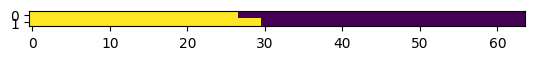

In [7]:
residue_mask = shard_residue_mask[:batch]
sequence_lengths = residue_mask.sum(dim=1)
plt.imshow(residue_mask.numpy())
residue_mask.shape, sequence_lengths

In [8]:
asym_id = shard_asym_id[:batch]
asym_id.shape, asym_id

(torch.Size([2, 64]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

In [9]:
residue_index = shard_residue_index[:batch]
residue_index.shape, residue_index

(torch.Size([2, 64]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21, 22, 23, 24, 25, 26, 27,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0]]))

In [10]:
mol_type = shard_mol_type[:batch]
mol_type.shape, mol_type

(torch.Size([2, 64]),
 tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
         [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]]))

torch.Size([2, 64])

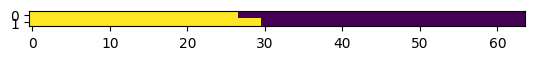

In [11]:
protein_mask = residue_mask & (mol_type == 0)
plt.imshow(protein_mask.numpy())
protein_mask.shape

### Input Masking

Now that we have our shard, we need to mask random locations in our sequence so that our model has something to predict and validate against during training. We'll use a high mask rate in this walkthrough so it's easy to see how residues get masked. For actual training, our PLM will use a lower mask rate (0.15), but, for production, the optimal mask rate could be found using hyper-parameter optimization. 

To do the masking, we'll also use a random generator and cutoff so there's variability from example to example in both what residue is masked and the number that are masked. Note that we use the special token `32` for masking, which is different from any standard residue ID. This lets the model know which positions need to be predicted. During loss analysis, we'll focus on these positions.

Notice that we also make a copy of our `input_ids` to create our targets. In this copy we flag every position except the masked positions with our `MLM_IGNORE_INDEX` of `-100`. This is the token configuration that tells the loss function to ignore the non-masked positions.


In [12]:
lm_mask_probability = 0.5
mask_generator = torch.Generator().manual_seed(seed)

torch.Size([2, 64])

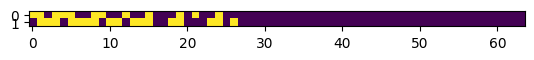

In [13]:
masked_ids, targets = tokenizer.mask_tokens(
    input_ids,
    protein_mask,
    mask_probability=lm_mask_probability,
    generator=mask_generator,
)
masked_positions = targets != MLM_IGNORE_INDEX
plt.imshow(masked_positions.numpy())
masked_positions.shape

In [14]:
masked_ids.shape, masked_ids

(torch.Size([2, 64]),
 tensor([[32, 32, 23, 32, 32, 32, 14,  4, 32, 32, 15, 15, 32,  4,  9, 32, 15, 11,
           9, 32,  9, 32,  4,  9, 32, 19, 12,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
         [18, 32, 32, 32, 21, 32, 32, 32, 32, 21, 32, 32,  9, 32, 32, 32,  4,  7,
          32, 32,  9, 10,  6, 32, 32, 19, 32, 14, 15,  5,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1]]))

In [15]:
targets.shape, targets

(torch.Size([2, 64]),
 tensor([[   5,   13, -100,    6,    4,   10, -100, -100,   18,    9, -100, -100,
             8, -100, -100,   13, -100, -100, -100,   10, -100,    4, -100, -100,
             8, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100],
         [-100,    7,   17,   16, -100,    4,   23,    6,    8, -100,    4,    7,
          -100,    5,    4,   19, -100, -100,   23,    6, -100, -100, -100,   18,
            18, -100,   11, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
          -100, -100, -100, -100]]))

### LM Wrapping

The final piece of our data prep is to insert the language-model boundary tokens. This primarily means adding BOS (beginning of sequence) and EOS (end of sequence) around each protein chain in the LM layout. These tokens are not in our cached shard because the cache needs residue tokens to stay aligned with residue and atom features and the BOS/EOS tokens are specific to the language model. We'll use our tokenizer to keep this processing clean and reusable in our full training.

Even though this cache is single-chain protein data, we still pass `asym_id`, `residue_index`, and `mol_type` into our lm wrapper. For a multi-chain protein, `asym_id` helps the wrapper split residues into separate chain segments so that separate BOS/EOS boundaries can be added per chain and separate sequence_id values can be assigned so attention stays chain-aware. The wrapper leverages the `residue_index` to deduplicate and order residues within chains and the `mol_type` acts as a filter to focus the chains only on proteins.  Because of this processing, we actually need to increase our context by $2*\text{num chains}$ to account for every pair of BOS/EOS tokens we add. 

In [16]:
default_context_size = masked_ids.shape[1]
lm_chain_count = 1
for batch_index in range(input_ids.size(0)):
    valid_chains = asym_id[batch_index, protein_mask[batch_index]]
    if int(valid_chains.numel()) > 0:
        lm_chain_count = max(lm_chain_count, int(valid_chains.unique().numel()))
lm_length = default_context_size + 2 * lm_chain_count

default_context_size, lm_chain_count, lm_length

(64, 1, 66)

In [17]:
lm_input_ids, lm_attention_mask, sequence_id, residue_to_lm_index = tokenizer.wrap_for_lm(
    masked_ids,
    residue_mask,
    asym_id=asym_id,
    residue_index=residue_index,
    mol_type=mol_type,
    lm_length=lm_length,
)
lm_context = lm_input_ids.size(1)

In [18]:
lm_input_ids, lm_input_ids.shape

(tensor([[ 0, 32, 32, 23, 32, 32, 32, 14,  4, 32, 32, 15, 15, 32,  4,  9, 32, 15,
          11,  9, 32,  9, 32,  4,  9, 32, 19, 12,  2,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1],
         [ 0, 18, 32, 32, 32, 21, 32, 32, 32, 32, 21, 32, 32,  9, 32, 32, 32,  4,
           7, 32, 32,  9, 10,  6, 32, 32, 19, 32, 14, 15,  5,  2,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1]]),
 torch.Size([2, 66]))

torch.Size([2, 66])

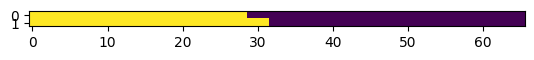

In [19]:
plt.imshow(lm_attention_mask.numpy())
lm_attention_mask.shape

In [20]:
sequence_id.shape, sequence_id, residue_to_lm_index.shape, residue_to_lm_index


(torch.Size([2, 66]),
 tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
         [ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
           0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1]]),
 torch.Size([2, 64]),
 tensor([[ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 21, 22, 23, 24, 25, 26, 27, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
          -1, -1, -1, -1, -1, -1, -1, -1, -1, -1],
         [ 1,  2,  3,  4,  5,  6,  7,  8,  9, 1

### Data Is Ready

At this point the tensors line up with the PLM forward pass. We have the `masked_ids` and `targets` that mirror the residue axis. `protein_mask` marks the residue rows that should produce PLM training and folding outputs. `lm_input_ids` is the BOS/EOS-wrapped version used by the transformer. `sequence_id` tells attention which wrapped tokens belong to the same chain, and `residue_to_lm_index` is how we return from the language-model layout back to residue positions for the folding pipeline.

In [21]:
masked_ids.shape, protein_mask.shape, lm_input_ids.shape, targets.shape, sequence_id.shape, residue_to_lm_index.shape

(torch.Size([2, 64]),
 torch.Size([2, 64]),
 torch.Size([2, 66]),
 torch.Size([2, 64]),
 torch.Size([2, 66]),
 torch.Size([2, 64]))

## Forward Pass

<img src="explainer_screenshots/2_plm/plm_overview.png" width="400">

The forward pass starts with token embeddings, runs a bidirectional transformer block, collects hidden states, gathers those hidden states back to the residue axis, and projects the final residue embeddings to masked-token logits.

Production PLMs tend to be much larger with more depth, heads, and embedding layers, but architecturally use the same components we'll walk through. 

### Input Token Embedding

We start by plucking out embedding representations of our residue IDs. Through training, this embedding layer can prove quite informative as it learns how different residues relate to one another and how they should be represented. As part of initializing this layer we'll also configure our padding ID `1` so that the layer knows that it is a padding embedding and so does not need gradients. You'll see this also initializes the layer weights to `0` for that specific embedding. The active PLM keeps the ESM-compatible vocabulary width at 64 even though this protein-only notebook only uses a smaller subset of those IDs.

See that because our examples are much shorter than the context they have significant padding which shows up as both of our examples ending with a lot of zero-embeddings.

Often LMs will then have a positional embedding to pair with the token embedding. For our PLM we'll actually use RoPE inside of attention to allow the model to learn from positional relationships instead of using a positional embedding.


In [22]:
embed_dim = 8
n_head = 2
head_dim = embed_dim // n_head
embed_dim, n_head, head_dim


(8, 2, 4)

In [23]:
token_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=ESM_PAD_ID)
token_embedding.weight.shape, token_embedding.weight

(torch.Size([33, 8]),
 Parameter containing:
 tensor([[ 1.9962e+00,  2.2376e+00,  1.0022e+00,  1.7236e+00,  8.1049e-01,
           8.0294e-02, -4.8770e-01,  2.9606e-01],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00,
           0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 9.9636e-01, -4.7531e-01,  9.3274e-01,  1.5002e+00,  8.4747e-01,
          -5.1535e-01,  1.2201e+00,  8.1169e-01],
         [ 1.2716e+00, -4.3535e-01, -1.4948e+00, -5.7577e-01,  5.2387e-01,
          -7.6814e-01,  1.5119e+00,  1.0151e+00],
         [-7.1872e-02, -3.9749e-01, -1.5815e+00, -1.0222e+00,  9.1559e-01,
           4.1106e-01,  2.9794e-02,  1.0440e+00],
         [ 3.3169e-01,  1.0903e+00,  4.7202e-01,  2.0445e+00,  3.9819e-02,
           4.5341e-02, -4.2942e-01, -3.6248e-02],
         [-7.4364e-01,  1.1353e+00, -2.7767e-01, -1.5316e+00,  1.6808e+00,
           1.2127e+00, -3.0543e-01,  9.1994e-01],
         [-1.1850e-01, -5.5145e-01,  6.8920e-01, -2.0459e+00,  4.2809e-01,
     

In [24]:
token_embeddings = token_embedding(lm_input_ids)
token_embeddings.shape, token_embeddings

(torch.Size([2, 66, 8]),
 tensor([[[ 1.9962,  2.2376,  1.0022,  ...,  0.0803, -0.4877,  0.2961],
          [-0.6834,  0.7661,  0.7149,  ...,  0.1312, -0.8429,  0.4128],
          [-0.6834,  0.7661,  0.7149,  ...,  0.1312, -0.8429,  0.4128],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 1.9962,  2.2376,  1.0022,  ...,  0.0803, -0.4877,  0.2961],
          [-0.4964,  0.3035,  0.6309,  ...,  1.3664, -0.1840, -0.7441],
          [-0.6834,  0.7661,  0.7149,  ...,  0.1312, -0.8429,  0.4128],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<EmbeddingBackward0>))

### Dropout

We'll now add a dropout layer. The dropout layer randomly (up to the configured frequency) zeros out values and adjusts remaining values by $1/(1-p)$. This dropout ensures that the model does not rely too much on the complete input, improving generalization of our model. This layer is dropped during eval as it is primarily a training aid. PyTorch does this automatically if you use the `Dropout` class. 

In [25]:
dropout_rate = 0.2
dropout = nn.Dropout(dropout_rate)
dropout

Dropout(p=0.2, inplace=False)

In [26]:
x = dropout(token_embeddings)
x.shape, x

(torch.Size([2, 66, 8]),
 tensor([[[ 2.4952,  2.7970,  1.2527,  ...,  0.1004, -0.6096,  0.3701],
          [-0.8543,  0.9577,  0.0000,  ...,  0.0000, -1.0537,  0.5160],
          [-0.8543,  0.9577,  0.8936,  ...,  0.0000, -0.0000,  0.5160],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.0000,  2.7970,  0.0000,  ...,  0.1004, -0.0000,  0.0000],
          [-0.6205,  0.3794,  0.7887,  ...,  1.7080, -0.0000, -0.9302],
          [-0.8543,  0.9577,  0.0000,  ...,  0.0000, -0.0000,  0.5160],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<MulBackward0>))

### Hidden State Stack - Initialize
One of the key outputs that the PLM provides the folding model is a deep representation of the protein sequence. To build that representation it collects the major representations of the protein, including the embedding projection and the representation of each transformer layer. We'll initialize the output now and add in our first representation, the post-dropout layer. 


In [27]:
hidden_state_stack = [x]
len(hidden_state_stack)

1

### Transformer Block

Our next step is the transformer block. While production models are likely to have multiple sequential blocks to add depth, we'll do just a single pass through. In this block we combine RoPE for positional learning, bi-directional attention, and then SwiGLU feed forward.

#### Transformer - Pre-attention Normalization

The first step in the transformer block is Layer Normalization. With this, we review each row's entries and adjust them based on how far away they are from the row mean. This means an array of `[1,2,3,4]` and `[2,4,6,8]` will actually have the same normalized entries after layer normalization. The formula applied is:

$y = \frac{x - \mathbb{E}[x]}{\sqrt{\operatorname{Var}[x] + \epsilon}}$

This layer is activated where each channel in the layer is weighted the same but, through learning, the weights can adjust. 

In [28]:
attn_norm = nn.LayerNorm(embed_dim)
attn_norm.weight, attn_norm.bias

(Parameter containing:
 tensor([1., 1., 1., 1., 1., 1., 1., 1.], requires_grad=True),
 Parameter containing:
 tensor([0., 0., 0., 0., 0., 0., 0., 0.], requires_grad=True))

In [29]:
x_norm = attn_norm(x)
x_norm.shape, x_norm

(torch.Size([2, 66, 8]),
 tensor([[[ 1.1417,  1.4070,  0.0493,  ..., -0.9639, -1.5881, -0.7267],
          [-0.5667,  1.5184,  0.4164,  ...,  0.4164, -0.7961,  1.0102],
          [-0.8062,  1.1790,  1.1088,  ...,  0.1298,  0.1298,  0.6951],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.7186,  1.9326, -0.7186,  ..., -0.6235, -0.7186, -0.7186],
          [-0.7122,  0.4037,  0.8604,  ...,  1.8864, -0.0197, -1.0578],
          [-0.7490,  1.4255,  0.2762,  ...,  0.2762,  0.2762,  0.8955],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

#### Transformer - Bidirectional Multi-Head Self-Attention

Since we're doing masked learning, we'll apply bidirectional self attention, or attention where each position can see all other allowed positions in the sequence, both upstream and downstream. The self attention means that the entries for query, key, and value are from the same input tensor (versus in cross-attention they differ).

Self attention uses 3 linear projections to create representations of 3 concepts to help predict the masked residue: query `Q`, key `K`, and value `V`. The attention layer takes the input `x` of shape $(\text{batch},\text{context},\text{embedding})$, linearly projects the last dimension to `Q, K, V` by multiplying each token vector $x_{b,c,:}$ with learned weight matrices, often via one combined QKV linear matrix.

The Q, K, and V matrices do the following:
* **Query** - the current position's search request. Every layer and head can learn to look for different sequence evidence, such as nearby chemistry, motif context, or longer-range residue patterns.
* **Key** - a matching tag/address for each allowed position. It is compared with the query to produce relevance scores.
* **Value** - the payload you actually mix in once something matches. It is a learned projection of the token's representation, so the model can move the right kind of sequence information into the current position.

After we have our Q, K, and V, we'll apply RoPE to the query and key so that attention can use position as part of its comparison. This is important in protein sequence learning because local and long-range sequence order both carry structure information.

*Note that in practice we'd use `F.scaled_dot_product_attention` for the module path, which avoids materializing the memory-intensive attention tensors we show here for teaching.*


##### Attention - Creating Q, K, and V

We'll start by creating a single linear layer to house our query, key, and value. We'll need to make it 3x as wide to allow the model to independently learn the different weights. You'll also notice that we haven't done "per head" splits yet. We'll do that split later but the width of our qkv will actually allow per head learning but, keeping it together simplifies the coding. 

In [30]:
batch, context, embed_dim = x_norm.size()
qkv_lin = nn.Linear(embed_dim, 3 * embed_dim, bias=False)
qkv_lin.weight.shape

torch.Size([24, 8])

In [31]:
qkv = qkv_lin(x_norm)
qkv.shape, qkv

(torch.Size([2, 66, 24]),
 tensor([[[-0.3767,  0.3578,  0.6879,  ...,  0.4470,  1.1747, -0.2974],
          [-1.4027, -0.2579,  0.4258,  ...,  0.1873, -0.3383, -0.1009],
          [-0.9576, -0.5111,  0.8194,  ..., -0.1156, -0.8135, -0.7551],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.8141, -0.8153,  0.3499,  ...,  0.6553,  0.9985, -0.1134],
          [ 0.2758,  0.1633, -0.3194,  ...,  0.5496,  0.0621, -0.6886],
          [-1.2587, -0.6121,  0.5789,  ..., -0.0651, -0.7576, -0.5058],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

##### Attention - Splitting Up Our Heads

Now that we've applied our Q, K, and V weights, we can do our per head split. As mentioned before, this split was done to simplify the math previously. All of our heads have the same width but, having different attention heads will give the model a chance to represent different concepts in different heads. There is a balance between having more heads for holding more abstract concepts and the embedding dimensions between heads. Because of this the number of heads is a common Bayesian optimization target. 

In [32]:
query, key, value = qkv.split(embed_dim, dim=-1)
query = query.view(batch, context, n_head, head_dim).transpose(1, 2)
key = key.view(batch, context, n_head, head_dim).transpose(1, 2)
value = value.view(batch, context, n_head, head_dim).transpose(1, 2)
'query', query.shape, query, 'key', key.shape, key, 'value', value.shape, value

('query',
 torch.Size([2, 2, 66, 4]),
 tensor([[[[-0.3767,  0.3578,  0.6879,  0.2353],
           [-1.4027, -0.2579,  0.4258, -0.5029],
           [-0.9576, -0.5111,  0.8194, -0.3929],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 1.1346,  0.3640,  0.7203, -0.3708],
           [ 0.0233, -0.2798,  0.2623,  1.0415],
           [-0.2366, -0.8089,  0.1387,  1.1649],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[-0.8141, -0.8153,  0.3499,  1.2525],
           [ 0.2758,  0.1633, -0.3194, -0.4319],
           [-1.2587, -0.6121,  0.5789, -0.3299],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.2700,

##### Attention - Q/K LayerNorm

In protein models, the query and key are often normalized before positional embeddings are added in. This helps keep the model behaving with deep training runs and large batch sizes. This is the same normalization that we applied before, just with its own weights. 

In [33]:
query_norm = nn.LayerNorm(head_dim)
query = query_norm(query)
query.shape, query

(torch.Size([2, 2, 66, 4]),
 tensor([[[[-1.5641e+00,  3.4180e-01,  1.1984e+00,  2.3897e-02],
           [-1.4794e+00,  2.6970e-01,  1.3144e+00, -1.0462e-01],
           [-1.0591e+00, -3.8070e-01,  1.6410e+00, -2.0111e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],
 
          [[ 1.2167e+00, -1.7728e-01,  4.6716e-01, -1.5066e+00],
           [-4.8736e-01, -1.1066e+00,  9.7235e-04,  1.5930e+00],
           [-4.1861e-01, -1.2142e+00,  1.0311e-01,  1.5297e+00],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]]],
 
 
         [[[-9.2940e-01, -9.3076e-01,  4.1060e-01,  1.4496e+00],
           [ 1.1684e+00,  7.9668e-01, -7.9676e-01, -1.1683e+00],
           [-1.2917e+

In [34]:
key_norm = nn.LayerNorm(head_dim)
key = key_norm(key)
key.shape, key

(torch.Size([2, 2, 66, 4]),
 tensor([[[[ 0.1080,  0.3697, -1.6059,  1.1281],
           [ 1.0073,  0.9883, -0.9048, -1.0908],
           [ 0.3176,  1.4401, -0.5043, -1.2533],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.2775, -0.2830, -1.3834,  1.3889],
           [ 0.4492, -1.4432,  1.2782, -0.2843],
           [ 0.4588, -0.7242,  1.4031, -1.1377],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[ 1.5698, -0.8250, -0.9097,  0.1649],
           [ 0.6725, -0.8639,  1.2753, -1.0839],
           [ 0.9678,  0.9548, -0.5720, -1.3507],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0158, -1.4328, 

##### Attention - Rotary Position Embedding (RoPE)

We want to give our model a way of being able to learn from the position of a residue. Rotary position embedding (RoPE) is the modern way. RoPE does not add a learned position vector to the hidden state. Instead, it rotates pairs of Q and K channels by an angle determined by sequence position. After that rotation, the dot product between Q and K can represent relative position information. 

Since RoPE puts position information directly into the Q/K attention comparison, attention can directly learn about relative offsets between residues instead of only seeing an added absolute position vector that's common if you use a positional embedding. RoPE also tends to generalize better across sequence lengths because the position signal is encoded as rotations in attention space rather than learned slots tied to fixed positions.

**Create RoPE angles per head**

First we'll need to create position indicators. Then we calculate a set of inverse frequencies so each RoPE channel pair rotates at a different amount, both high and low. We then apply those frequencies to the position to turn them into angles. Once we have the angles we can apply sin and cosine to get the scalars for our query and key. 

In [35]:
rotary_pairs = head_dim // 2
positions = torch.arange(context)
rotary_pairs, positions

(2,
 tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
         18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
         36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
         54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]))

In [36]:
rotary_frequencies = 1.0 / (10000 ** (torch.arange(rotary_pairs, dtype=query.dtype) / rotary_pairs))
rotary_frequencies.shape, rotary_frequencies

(torch.Size([2]), tensor([1.0000, 0.0100]))

In [37]:
rotary_angles = positions.unsqueeze(-1) * rotary_frequencies.unsqueeze(0)
rotary_angles.shape, rotary_angles

(torch.Size([66, 2]),
 tensor([[0.0000e+00, 0.0000e+00],
         [1.0000e+00, 1.0000e-02],
         [2.0000e+00, 2.0000e-02],
         [3.0000e+00, 3.0000e-02],
         [4.0000e+00, 4.0000e-02],
         [5.0000e+00, 5.0000e-02],
         [6.0000e+00, 6.0000e-02],
         [7.0000e+00, 7.0000e-02],
         [8.0000e+00, 8.0000e-02],
         [9.0000e+00, 9.0000e-02],
         [1.0000e+01, 1.0000e-01],
         [1.1000e+01, 1.1000e-01],
         [1.2000e+01, 1.2000e-01],
         [1.3000e+01, 1.3000e-01],
         [1.4000e+01, 1.4000e-01],
         [1.5000e+01, 1.5000e-01],
         [1.6000e+01, 1.6000e-01],
         [1.7000e+01, 1.7000e-01],
         [1.8000e+01, 1.8000e-01],
         [1.9000e+01, 1.9000e-01],
         [2.0000e+01, 2.0000e-01],
         [2.1000e+01, 2.1000e-01],
         [2.2000e+01, 2.2000e-01],
         [2.3000e+01, 2.3000e-01],
         [2.4000e+01, 2.4000e-01],
         [2.5000e+01, 2.5000e-01],
         [2.6000e+01, 2.6000e-01],
         [2.7000e+01, 2.7000e-01]

In [38]:
rotary_cos = torch.cos(rotary_angles)[None, None, :, :]
rotary_cos.shape, rotary_cos

(torch.Size([1, 1, 66, 2]),
 tensor([[[[ 1.0000,  1.0000],
           [ 0.5403,  0.9999],
           [-0.4161,  0.9998],
           [-0.9900,  0.9996],
           [-0.6536,  0.9992],
           [ 0.2837,  0.9988],
           [ 0.9602,  0.9982],
           [ 0.7539,  0.9976],
           [-0.1455,  0.9968],
           [-0.9111,  0.9960],
           [-0.8391,  0.9950],
           [ 0.0044,  0.9940],
           [ 0.8439,  0.9928],
           [ 0.9074,  0.9916],
           [ 0.1367,  0.9902],
           [-0.7597,  0.9888],
           [-0.9577,  0.9872],
           [-0.2752,  0.9856],
           [ 0.6603,  0.9838],
           [ 0.9887,  0.9820],
           [ 0.4081,  0.9801],
           [-0.5477,  0.9780],
           [-1.0000,  0.9759],
           [-0.5328,  0.9737],
           [ 0.4242,  0.9713],
           [ 0.9912,  0.9689],
           [ 0.6469,  0.9664],
           [-0.2921,  0.9638],
           [-0.9626,  0.9611],
           [-0.7481,  0.9582],
           [ 0.1543,  0.9553],
           

In [39]:
rotary_sin = torch.sin(rotary_angles)[None, None, :, :]
rotary_sin.shape, rotary_sin

(torch.Size([1, 1, 66, 2]),
 tensor([[[[ 0.0000,  0.0000],
           [ 0.8415,  0.0100],
           [ 0.9093,  0.0200],
           [ 0.1411,  0.0300],
           [-0.7568,  0.0400],
           [-0.9589,  0.0500],
           [-0.2794,  0.0600],
           [ 0.6570,  0.0699],
           [ 0.9894,  0.0799],
           [ 0.4121,  0.0899],
           [-0.5440,  0.0998],
           [-1.0000,  0.1098],
           [-0.5366,  0.1197],
           [ 0.4202,  0.1296],
           [ 0.9906,  0.1395],
           [ 0.6503,  0.1494],
           [-0.2879,  0.1593],
           [-0.9614,  0.1692],
           [-0.7510,  0.1790],
           [ 0.1499,  0.1889],
           [ 0.9129,  0.1987],
           [ 0.8367,  0.2085],
           [-0.0089,  0.2182],
           [-0.8462,  0.2280],
           [-0.9056,  0.2377],
           [-0.1324,  0.2474],
           [ 0.7626,  0.2571],
           [ 0.9564,  0.2667],
           [ 0.2709,  0.2764],
           [-0.6636,  0.2860],
           [-0.9880,  0.2955],
           

**RoPE - Apply to Query**

We first reshape Query to insert in our rotary pairs dimension into each head. We then extract out each value in the pair, and apply our rotation. After that we then unstack our matrix back down to per head values. We calculate the RoPE embeddings as:

$$
\begin{aligned}
x'_{p,i,0} &= x_{p,i,0}\cos\theta_{p,i} - x_{p,i,1}\sin\theta_{p,i} \\
x'_{p,i,1} &= x_{p,i,0}\sin\theta_{p,i} + x_{p,i,1}\cos\theta_{p,i}
\end{aligned}
$$


In [40]:
q_pairs = query.view(batch, n_head, context, rotary_pairs, 2)
q_pairs.shape, q_pairs

(torch.Size([2, 2, 66, 2, 2]),
 tensor([[[[[-1.5641e+00,  3.4180e-01],
            [ 1.1984e+00,  2.3897e-02]],
 
           [[-1.4794e+00,  2.6970e-01],
            [ 1.3144e+00, -1.0462e-01]],
 
           [[-1.0591e+00, -3.8070e-01],
            [ 1.6410e+00, -2.0111e-01]],
 
           ...,
 
           [[ 0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  0.0000e+00]],
 
           [[ 0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  0.0000e+00]],
 
           [[ 0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  0.0000e+00]]],
 
 
          [[[ 1.2167e+00, -1.7728e-01],
            [ 4.6716e-01, -1.5066e+00]],
 
           [[-4.8736e-01, -1.1066e+00],
            [ 9.7235e-04,  1.5930e+00]],
 
           [[-4.1861e-01, -1.2142e+00],
            [ 1.0311e-01,  1.5297e+00]],
 
           ...,
 
           [[ 0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  0.0000e+00]],
 
           [[ 0.0000e+00,  0.0000e+00],
            [ 0.0000e+00,  0.0000e+00]],
 
           [[ 0.0

In [41]:
q_first = q_pairs.select(dim=-1, index=0)
q_first.shape, q_first

(torch.Size([2, 2, 66, 2]),
 tensor([[[[-1.5641e+00,  1.1984e+00],
           [-1.4794e+00,  1.3144e+00],
           [-1.0591e+00,  1.6410e+00],
           [-6.9524e-01, -1.2113e+00],
           [-1.0663e+00,  1.6418e+00],
           [-1.0189e+00,  1.2962e+00],
           [-1.2558e+00,  1.4673e+00],
           [ 2.8627e-01, -1.1703e+00],
           [-1.4463e-01, -4.0833e-01],
           [-8.2849e-01,  1.2001e+00],
           [-1.6058e+00,  1.1418e+00],
           [-1.5580e+00, -1.6021e-01],
           [-2.2099e-01,  7.4680e-02],
           [-1.1569e+00,  1.5626e+00],
           [ 8.0416e-01, -1.2324e+00],
           [ 1.6086e+00, -1.0395e+00],
           [-7.1160e-01,  1.4088e+00],
           [-1.5812e+00,  3.1438e-01],
           [ 2.1848e-01, -1.4126e+00],
           [ 1.5089e+00, -6.2876e-01],
           [-1.2558e+00,  1.4673e+00],
           [ 1.6575e+00, -4.9497e-01],
           [-9.5125e-01,  1.4385e+00],
           [-2.2301e-01, -1.5423e+00],
           [ 1.6575e+00, -4.9497e-01

In [42]:
q_second = q_pairs.select(dim=-1, index=1)
q_second.shape, q_second

(torch.Size([2, 2, 66, 2]),
 tensor([[[[ 0.3418,  0.0239],
           [ 0.2697, -0.1046],
           [-0.3807, -0.2011],
           [ 0.6129,  1.2937],
           [-0.3190, -0.2565],
           [ 0.6497, -0.9270],
           [ 0.2459, -0.4574],
           [ 1.4807, -0.5966],
           [ 1.6290, -1.0761],
           [ 0.7640, -1.1356],
           [ 0.1612,  0.3028],
           [ 1.0467,  0.6715],
           [-1.3295,  1.4758],
           [ 0.0593, -0.4650],
           [-0.7193,  1.1476],
           [ 0.0069, -0.5760],
           [ 0.4469, -1.1441],
           [ 0.0865,  1.1803],
           [ 1.3857, -0.1916],
           [ 0.2457, -1.1258],
           [ 0.2459, -0.4574],
           [-0.1738, -0.9887],
           [ 0.4299, -0.9171],
           [ 0.8011,  0.9642],
           [-0.1738, -0.9887],
           [-0.6843,  0.6095],
           [-0.2177, -0.3842],
           [-1.0997,  0.1747],
           [-0.8140, -0.9877],
           [ 0.0000,  0.0000],
           [ 0.0000,  0.0000],
           

In [43]:
q_sub = q_first * rotary_cos - q_second * rotary_sin
q_add = q_first * rotary_sin + q_second * rotary_cos
q_rotated = torch.stack([q_sub,q_add],dim=-1)
q_rotated.shape, q_rotated

(torch.Size([2, 2, 66, 2, 2]),
 tensor([[[[[-1.5641,  0.3418],
            [ 1.1984,  0.0239]],
 
           [[-1.0263, -1.0992],
            [ 1.3153, -0.0915]],
 
           [[ 0.7869, -0.8047],
            [ 1.6447, -0.1683]],
 
           ...,
 
           [[ 0.0000,  0.0000],
            [ 0.0000,  0.0000]],
 
           [[ 0.0000,  0.0000],
            [ 0.0000,  0.0000]],
 
           [[-0.0000,  0.0000],
            [ 0.0000,  0.0000]]],
 
 
          [[[ 1.2167, -0.1773],
            [ 0.4672, -1.5066]],
 
           [[ 0.6679, -1.0080],
            [-0.0150,  1.5929]],
 
           [[ 1.2782,  0.1246],
            [ 0.0725,  1.5314]],
 
           ...,
 
           [[ 0.0000,  0.0000],
            [ 0.0000,  0.0000]],
 
           [[ 0.0000,  0.0000],
            [ 0.0000,  0.0000]],
 
           [[-0.0000,  0.0000],
            [ 0.0000,  0.0000]]]],
 
 
 
         [[[[-0.9294, -0.9308],
            [ 0.4106,  1.4496]],
 
           [[-0.0391,  1.4136],
            [-0.7850,

In [44]:
query = q_rotated.view(batch, n_head, context, head_dim)
query.shape, query

(torch.Size([2, 2, 66, 4]),
 tensor([[[[-1.5641,  0.3418,  1.1984,  0.0239],
           [-1.0263, -1.0992,  1.3153, -0.0915],
           [ 0.7869, -0.8047,  1.6447, -0.1683],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 1.2167, -0.1773,  0.4672, -1.5066],
           [ 0.6679, -1.0080, -0.0150,  1.5929],
           [ 1.2782,  0.1246,  0.0725,  1.5314],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[-0.9294, -0.9308,  0.4106,  1.4496],
           [-0.0391,  1.4136, -0.7850, -1.1762],
           [ 0.8220, -1.0443,  1.4875,  0.1442],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.7676,  0.7493, 

**RoPE - Apply to Key**

We'll now apply the same calculation to the Key value. We'll consolidate it into a formula to simplify.

In [45]:
def apply_rotary(tensor):
    tensor_pairs = tensor.view(batch, n_head, context, rotary_pairs, 2)
    first, second = tensor_pairs.unbind(dim=-1)
    rotated = torch.stack(
        [
            first * rotary_cos - second * rotary_sin,
            first * rotary_sin + second * rotary_cos,
        ],
        dim=-1,
    )
    return rotated.view(batch, n_head, context, head_dim)


In [46]:
key = apply_rotary(key)
key.shape, key

(torch.Size([2, 2, 66, 4]),
 tensor([[[[ 0.1080,  0.3697, -1.6059,  1.1281],
           [-0.2873,  1.3816, -0.8939, -1.0998],
           [-1.4416, -0.3105, -0.4791, -1.2632],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.2775, -0.2830, -1.3834,  1.3889],
           [ 1.4571, -0.4017,  1.2810, -0.2715],
           [ 0.4676,  0.7186,  1.4256, -1.1094],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[ 1.5698, -0.8250, -0.9097,  0.1649],
           [ 1.0903,  0.0991,  1.2860, -1.0711],
           [-1.2710,  0.4827, -0.5449, -1.3618],
           ...,
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  0.0000],
           [-0.0000,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0158, -1.4328, 

##### Attention - Scaled Query Key

With rotary-applied Q and K, we calculate the unnormalized attention. We divide by the `sqrt(head_dim)` to keep the dot product from growing too large as head width increases. The dot product at this level allows every embedding dim to interact with every other embedding dim. 

In [47]:
scale = 1.0 / math.sqrt(head_dim)
scale

0.5

In [48]:
attention_scores = query @ key.transpose(-2, -1) * scale
attention_scores.shape, attention_scores

(torch.Size([2, 2, 66, 66]),
 tensor([[[[-0.9700, -0.0879,  0.7721,  ...,  0.0000,  0.0000,  0.0000],
           [-1.3663, -1.1494,  0.6531,  ...,  0.0000,  0.0000,  0.0000],
           [-1.5217, -1.3114, -0.7300,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[-1.1754,  1.4257,  1.3895,  ...,  0.0000,  0.0000,  0.0000],
           [ 1.3519,  0.4633, -1.1003,  ...,  0.0000,  0.0000,  0.0000],
           [ 1.1731,  0.7448, -0.4542,  ...,  0.0000,  0.0000,  0.0000],
           ...,
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[-0.4128, -1.0651, -0.7329,  ...,  0.0000, 

##### Attention - Masking

Before we convert our attention scores into probabilities, we need to ensure that disallowed positions get a very negative score so they will turn into zero-probability positions after softmax. While we could use `lm_attention_mask`, we'll actually rederive a mask from `sequence_id` so that, for each example sequence, tokens can only attend to tokens from the same chain or sequence segment. In practice, we use `torch.finfo(attention_scores.dtype).min`, the most negative finite value for the tensor dtype, instead of literal $-\infty$ so padded query rows do not produce NaNs.

We start with `sequence_id`, which marks which wrapped LM tokens belong to the same chain, while padded positions use `-1`. Our comparison builds a `[Batch, 1, Context, Context]` map saying which query/key token pairs are allowed to see each other because they belong to the same sequence segment. Then the two `valid_sequence` masks remove padded query and key positions. After that, `masked_fill` sets every disallowed attention score to the very negative value.


In [49]:
valid_sequence = sequence_id >= 0
valid_sequence.shape, valid_sequence

(torch.Size([2, 66]),
 tensor([[ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False],
         [ True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True,  True,  True,  True,  True,  True,  True,  True,  True,
           True,  True, False, False, False, False, False, False, False, False,
          False, False, False, False, False, False, False, False, False, False,
          False, False, False, False, False, 

In [50]:
#  allow attention only between tokens with the same sequence_id.
attention_allowed = sequence_id[:, None, :, None] == sequence_id[:, None, None, :]
# remove rows where the query token is padding / invalid.
attention_allowed = attention_allowed & valid_sequence[:, None, :, None]
# remove columns where the key token is padding / invalid.
attention_allowed = attention_allowed & valid_sequence[:, None, None, :]
attention_allowed.shape, attention_allowed

(torch.Size([2, 1, 66, 66]),
 tensor([[[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]],
 
 
         [[[ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           [ True,  True,  True,  ..., False, False, False],
           ...,
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False],
           [False, False, False,  ..., False, False, False]]]]))

In [51]:
attention_scores = attention_scores.masked_fill(
    ~attention_allowed,
    torch.finfo(attention_scores.dtype).min,
)
attention_scores.shape, attention_scores

(torch.Size([2, 2, 66, 66]),
 tensor([[[[-9.7002e-01, -8.7899e-02,  7.7213e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.3663e+00, -1.1494e+00,  6.5308e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-1.5217e+00, -1.3114e+00, -7.3002e-01,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           ...,
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [-3.4028e+38, -3.4028e+38, -3.4028e+38,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38]],
 
          [[-1.1754e+00,  1.4257e+00,  1.3895e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.3519e+00,  4.6327e-01, -1.1003e+00,  ..., -3.4028e+38,
            -3.4028e+38, -3.4028e+38],
           [ 1.1731e+00,  7.4481e-01, -4.5419e-01,  ..., -3.4028e+38,
          

##### Attention - Softmax

Now that we have our masking in place we need to convert our attention scores to a probability. While we previously masked invalid key positions and sequence segments, padded query rows can still produce a softmax output, so we'll multiply by our valid sequences to set those rows to zero also. 


In [52]:
attention_weights = F.softmax(attention_scores, dim=-1)
attention_weights = attention_weights * valid_sequence[:, None, :, None]
attention_weights.shape, attention_weights


(torch.Size([2, 2, 66, 66]),
 tensor([[[[0.0093, 0.0224, 0.0530,  ..., 0.0000, 0.0000, 0.0000],
           [0.0056, 0.0070, 0.0425,  ..., 0.0000, 0.0000, 0.0000],
           [0.0049, 0.0061, 0.0108,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0065, 0.0880, 0.0848,  ..., 0.0000, 0.0000, 0.0000],
           [0.0929, 0.0382, 0.0080,  ..., 0.0000, 0.0000, 0.0000],
           [0.0806, 0.0525, 0.0158,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0189, 0.0098, 0.0137,  ..., 0.0000, 0.0000, 0.0000],
           [0.0095, 0.0161, 0.0539,  ..., 0.0000, 0.0000, 0

##### Attention - Dropout
We'll do another layer dropout to support generalization. This is the same style of dropout as we did before so it will scale up values that remain. 

In [53]:
attention_dropout = nn.Dropout(dropout_rate)
attention_weights = attention_dropout(attention_weights)
attention_weights.shape, attention_weights

(torch.Size([2, 2, 66, 66]),
 tensor([[[[0.0000, 0.0280, 0.0662,  ..., 0.0000, 0.0000, 0.0000],
           [0.0070, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0061, 0.0076, 0.0135,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
 
          [[0.0082, 0.1099, 0.1060,  ..., 0.0000, 0.0000, 0.0000],
           [0.1161, 0.0477, 0.0100,  ..., 0.0000, 0.0000, 0.0000],
           [0.1008, 0.0657, 0.0198,  ..., 0.0000, 0.0000, 0.0000],
           ...,
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],
 
 
         [[[0.0000, 0.0000, 0.0171,  ..., 0.0000, 0.0000, 0.0000],
           [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0

##### Attention - Value Extraction

Finally we can now take the attention weights and use them to weight the values. This gives each query position a weighted blend of the information it attended to.

In [54]:
x_attn = attention_weights @ value
x_attn.shape, x_attn

(torch.Size([2, 2, 66, 4]),
 tensor([[[[-6.6728e-02, -4.0157e-03,  1.1328e-01, -9.5297e-02],
           [-3.0619e-02, -1.8192e-01, -2.1663e-02,  1.6073e-02],
           [ 2.9012e-02, -1.9681e-01, -1.6051e-01,  2.5050e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]],
 
          [[ 2.8806e-01, -7.7111e-02, -3.2753e-01,  4.2351e-02],
           [ 3.3939e-01,  7.3373e-02, -1.0360e-01,  1.9764e-02],
           [ 3.3203e-01,  2.3106e-01,  1.0943e-01,  1.3096e-01],
           ...,
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00],
           [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  0.0000e+00]]],
 
 
         [[[ 1.0418e-01,  1.9290e-01, -1.6465e-02, -8.3663e-02],
           [-9.8589e-02, -2.7363e-01, -2.8189e-01,  9.6104e-02],
           [ 3.3530e-

##### Attention - Head Collapsing

We can now remove the heads for the remainder of our attention. This simply means collapsing back our head dimension. We use contiguous here to improve the backend efficiency. 

In [55]:
x_attn = x_attn.transpose(1, 2).contiguous().view(batch, context, embed_dim)
x_attn.shape, x_attn

(torch.Size([2, 66, 8]),
 tensor([[[-6.6728e-02, -4.0157e-03,  1.1328e-01,  ..., -7.7111e-02,
           -3.2753e-01,  4.2351e-02],
          [-3.0619e-02, -1.8192e-01, -2.1663e-02,  ...,  7.3373e-02,
           -1.0360e-01,  1.9764e-02],
          [ 2.9012e-02, -1.9681e-01, -1.6051e-01,  ...,  2.3106e-01,
            1.0943e-01,  1.3096e-01],
          ...,
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00],
          [ 0.0000e+00,  0.0000e+00,  0.0000e+00,  ...,  0.0000e+00,
            0.0000e+00,  0.0000e+00]],
 
         [[ 1.0418e-01,  1.9290e-01, -1.6465e-02,  ...,  7.1020e-02,
           -2.7597e-01, -3.3281e-01],
          [-9.8589e-02, -2.7363e-01, -2.8189e-01,  ...,  9.7085e-02,
           -1.3165e-01, -1.9554e-01],
          [ 3.3530e-02,  9.3039e-02, -1.0260e-04,  ...,  1.2923e-01,
           -8.2010e-02, -1.8656e

##### Attention - Final Linear Projection
As the final step of attention we will now project the self attention matrix on another final linear layer. Notice that again we remove the bias, something common in protein models. After this projection, the active module still clears padded positions, which keeps the residual stream from carrying values for padding tokens. 


In [56]:
out_lin = nn.Linear(embed_dim, embed_dim, bias=False)
out_lin.weight.shape

torch.Size([8, 8])

In [57]:
x_attn = out_lin(x_attn)
x_attn.shape, x_attn

(torch.Size([2, 66, 8]),
 tensor([[[ 0.0678, -0.0540, -0.0141,  ...,  0.0497,  0.0050,  0.0086],
          [ 0.0235, -0.1272,  0.0147,  ..., -0.0117,  0.0437, -0.1387],
          [ 0.0109, -0.1219,  0.0657,  ..., -0.1410,  0.0778, -0.2414],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.0042, -0.0691, -0.0054,  ...,  0.1177, -0.0649,  0.1610],
          [ 0.0642, -0.0910,  0.1000,  ...,  0.1551,  0.0615, -0.1161],
          [-0.0396, -0.0984,  0.0123,  ..., -0.0254, -0.0714, -0.0108],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

#### Post Attention Residual Connection

Now we add the attention output back to the incoming hidden state. The residual connection gives each layer a direct path for information and gradients while still letting attention contribute an update. We do this by calculating:
$$
y = f(x) + x
$$
In application, this means adding our attention update to the attention input.


In [58]:
x = x + x_attn
x.shape, x

(torch.Size([2, 66, 8]),
 tensor([[[ 2.5630,  2.7429,  1.2386,  ...,  0.1500, -0.6046,  0.3787],
          [-0.8308,  0.8305,  0.0147,  ..., -0.0117, -1.0100,  0.3774],
          [-0.8434,  0.8358,  0.9592,  ..., -0.1410,  0.0778,  0.2747],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.0042,  2.7279, -0.0054,  ...,  0.2181, -0.0649,  0.1610],
          [-0.5563,  0.2884,  0.8887,  ...,  1.8632,  0.0615, -1.0463],
          [-0.8939,  0.8593,  0.0123,  ..., -0.0254, -0.0714,  0.5053],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<AddBackward0>))

#### Pre-MLP Normalization

Before our next component of our transformer block we'll do another layer normalization. This again applies the same normalization formula ensuring our weights remain manageable. 

In [59]:
mlp_norm = nn.LayerNorm(embed_dim)
x_norm2 = mlp_norm(x)
x_norm2.shape, x_norm2

(torch.Size([2, 66, 8]),
 tensor([[[ 1.1892,  1.3470,  0.0279,  ..., -0.9266, -1.5884, -0.7261],
          [-0.5275,  1.4970,  0.5029,  ...,  0.4708, -0.7459,  0.9449],
          [-0.6981,  1.1283,  1.2625,  ...,  0.0659,  0.3039,  0.5180],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.7597,  1.8544, -0.7608,  ..., -0.5470, -0.8177, -0.6016],
          [-0.5875,  0.2893,  0.9124,  ...,  1.9240,  0.0538, -1.0962],
          [-0.7946,  1.4042,  0.3420,  ...,  0.2946,  0.2370,  0.9602],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

#### SwiGLU MLP

Modern PLMs use a SwiGLU-based feed forward block. The benefit of SwiGLU is that it inserts in a learned gate to control the values as they flow through our network instead of just a nonlinearity, giving the model the ability to learn more complex relationships. By using a learned gate multiplied by the values themselves, SwiGLU avoids compressing the space like tanh (which compresses to $[-1,1]$. 

##### MLP - Linear Up/Gate Projection

We start SwiGLU with the traditional up-projection linear layer with the difference being we actually go double the width. The reason we double this is because we need the projection for both the gate and the values. 

In [60]:
mlp_scale = 4
mlp_fc = nn.Linear(embed_dim, 2 * mlp_scale * embed_dim, bias=False)
mlp_fc.weight.shape

torch.Size([64, 8])

In [61]:
x_mlp = mlp_fc(x_norm2)
x_mlp.shape, x_mlp

(torch.Size([2, 66, 64]),
 tensor([[[ 0.2195, -1.4774, -0.0222,  ..., -0.3677, -0.5513, -0.2194],
          [-0.1080, -0.3439, -0.0681,  ..., -0.3760,  0.6126, -0.8617],
          [ 0.1028, -0.1813, -0.0037,  ..., -0.4390,  0.9302, -0.6495],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.4361, -0.4970, -1.0899,  ...,  0.1314, -0.4301,  0.1639],
          [ 1.3317,  0.3381,  0.1971,  ..., -0.6786,  0.4789, -0.3715],
          [-0.1624, -0.0054, -0.2926,  ..., -0.3542,  0.9468, -0.6420],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

##### MLP - Extract Gate and Values

Now we split the expanded tensor into the gate and value branches.

In [62]:
gate, values = x_mlp.chunk(2, dim=-1)
gate.shape, values.shape

(torch.Size([2, 66, 32]), torch.Size([2, 66, 32]))

##### MLP - Apply SiLU Gated Nonlinearity

The SiLU gate controls how much of each value channel passes through. SiLU is calculated as:
$$
\begin{aligned}
\operatorname{SiLU}(x) &= x \cdot \sigma(x) \\
&= \frac{x}{1 + e^{-x}}
\end{aligned}
$$

By including the sigma in the gate, the model can modulate a value between zero and 1.

In [63]:
gate = F.silu(gate)
gate.shape, gate

(torch.Size([2, 66, 32]),
 tensor([[[ 0.1218, -0.2745, -0.0110,  ..., -0.2040,  0.4886,  0.4589],
          [-0.0511, -0.1427, -0.0329,  ..., -0.1881,  0.0657, -0.2707],
          [ 0.0540, -0.0825, -0.0018,  ..., -0.0537, -0.0795, -0.2515],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 0.2648, -0.1880, -0.2743,  ..., -0.2728,  0.0216,  0.5764],
          [ 1.0535,  0.1974,  0.1082,  ...,  0.4613,  0.4916, -0.1617],
          [-0.0746, -0.0027, -0.1250,  ..., -0.1372, -0.1579, -0.2665],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<SiluBackward0>))

In [64]:
x_mlp = gate * values
x_mlp.shape, x_mlp

(torch.Size([2, 66, 32]),
 tensor([[[ 0.0157,  0.0700,  0.0065,  ...,  0.0750, -0.2694, -0.1007],
          [ 0.0532,  0.0278, -0.0115,  ...,  0.0707,  0.0402,  0.2333],
          [-0.0346,  0.0068, -0.0005,  ...,  0.0236, -0.0740,  0.1634],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.1475,  0.1316,  0.1143,  ..., -0.0359, -0.0093,  0.0944],
          [ 0.3507, -0.0651, -0.0052,  ..., -0.3130,  0.2355,  0.0601],
          [ 0.0759,  0.0006, -0.0660,  ...,  0.0486, -0.1495,  0.1711],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<MulBackward0>))

##### MLP - Linear Down-Projection

Now we'll project back down to our incoming dimensions. 

In [65]:
mlp_proj = nn.Linear(mlp_scale * embed_dim, embed_dim, bias=False)
mlp_proj.weight.shape

torch.Size([8, 32])

In [66]:
x_mlp = mlp_proj(x_mlp)
x_mlp.shape, x_mlp

(torch.Size([2, 66, 8]),
 tensor([[[ 0.0719, -0.0395,  0.0131,  ..., -0.0359,  0.0260, -0.1211],
          [-0.1947, -0.0672,  0.1839,  ...,  0.0966, -0.0237,  0.0803],
          [-0.0537, -0.0515,  0.0767,  ...,  0.1367, -0.0328,  0.0351],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.0130, -0.0488,  0.1869,  ..., -0.1108,  0.0490, -0.1005],
          [-0.0361, -0.0388, -0.0829,  ...,  0.0333, -0.0016,  0.1147],
          [-0.1368, -0.0808,  0.1343,  ...,  0.1356,  0.0039,  0.0904],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<UnsafeViewBackward0>))

#### Post MLP Residual Connection

We add another residual connection after the MLP so the block can preserve the incoming hidden state while learning a feed-forward update.


In [67]:
x = x + x_mlp
x.shape, x

(torch.Size([2, 66, 8]),
 tensor([[[ 2.6349,  2.7034,  1.2517,  ...,  0.1141, -0.5787,  0.2576],
          [-1.0255,  0.7632,  0.1986,  ...,  0.0849, -1.0337,  0.4577],
          [-0.8970,  0.7842,  1.0359,  ..., -0.0042,  0.0451,  0.3098],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.0172,  2.6791,  0.1815,  ...,  0.1072, -0.0160,  0.0606],
          [-0.5924,  0.2496,  0.8058,  ...,  1.8965,  0.0599, -0.9316],
          [-1.0307,  0.7786,  0.1467,  ...,  0.1101, -0.0675,  0.5956],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<AddBackward0>))

### Hidden State Stack - Add Transformer Layers

Recall that we've previously initiated the hidden state collection with our pre-transformer representation. As each transformer layer completes, we add the layer's representation to the hidden layer giving our protein model more information. Since this explainer has one transformer block, we'll end with two layer entries after final normalization.


In [68]:
hidden_state_stack.append(x)
len(hidden_state_stack), [hidden.shape for hidden in hidden_state_stack]

(2, [torch.Size([2, 66, 8]), torch.Size([2, 66, 8])])

### Post Transformer Block Normalization

After the transformer stack, we do a final normalization before doing our output projections. This is the same layer normalization calculation we've previously done. The model stores this normalized transformer result as the last hidden-state layer, so the hidden-state stack matches what `LanguageModelShim` consumes later.


In [69]:
final_norm = nn.LayerNorm(embed_dim)
x = final_norm(x)
x.shape, x

(torch.Size([2, 66, 8]),
 tensor([[[ 1.2684,  1.3286,  0.0528,  ..., -0.9469, -1.5557, -0.8209],
          [-0.7859,  1.3937,  0.7057,  ...,  0.5672, -0.7959,  1.0214],
          [-0.7795,  1.0549,  1.3295,  ...,  0.1946,  0.2484,  0.5372],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.7745,  1.7763, -0.5865,  ..., -0.6568, -0.7733, -0.7009],
          [-0.5940,  0.2671,  0.8358,  ...,  1.9510,  0.0730, -0.9408],
          [-0.9810,  1.2629,  0.4792,  ...,  0.4339,  0.2136,  1.0361],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

### Hidden State Stack - Replace Last Entry

Now that we have the normalized final representation of the transformer output, we'll actually replace the final transformer output layer in our hidden states with the normalized value. This ensures we have a robust final representation. We'll then adjust our tensor to have a per example, per residue, per layer, per embedding representation. 


In [70]:
hidden_state_stack[-1] = x
lm_hidden_states = torch.stack(hidden_state_stack, dim=2)
lm_hidden_states.shape, lm_hidden_states

(torch.Size([2, 66, 2, 8]),
 tensor([[[[ 2.4952,  2.7970,  1.2527,  ...,  0.1004, -0.6096,  0.3701],
           [ 1.2684,  1.3286,  0.0528,  ..., -0.9469, -1.5557, -0.8209]],
 
          [[-0.8543,  0.9577,  0.0000,  ...,  0.0000, -1.0537,  0.5160],
           [-0.7859,  1.3937,  0.7057,  ...,  0.5672, -0.7959,  1.0214]],
 
          [[-0.8543,  0.9577,  0.8936,  ...,  0.0000, -0.0000,  0.5160],
           [-0.7795,  1.0549,  1.3295,  ...,  0.1946,  0.2484,  0.5372]],
 
          ...,
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
 
 
         [[[ 0.0000,  2.7970,  0.0000,  ...,  0.1004, -0.0

### Output - Hidden State Collection

Once the transformer block and final normalization have run we are ready to stage our first output. The first output is `hidden_states`, a collection of LM states reindexed back to the original residue positions. The hidden state is stacked to `[batch, residue, layer, embedding]` with our layers going sequentially through. We'll first create indexes that help us adjust out hidden layer tensor to fit the output. 

In [71]:
residue_gather_index = residue_to_lm_index.clamp_min(0).unsqueeze(-1).expand(-1, -1, embed_dim)
residue_gather_index.shape, residue_gather_index

(torch.Size([2, 64, 8]),
 tensor([[[1, 1, 1,  ..., 1, 1, 1],
          [2, 2, 2,  ..., 2, 2, 2],
          [3, 3, 3,  ..., 3, 3, 3],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]],
 
         [[1, 1, 1,  ..., 1, 1, 1],
          [2, 2, 2,  ..., 2, 2, 2],
          [3, 3, 3,  ..., 3, 3, 3],
          ...,
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0],
          [0, 0, 0,  ..., 0, 0, 0]]]))

In [72]:
layer_gather_index = residue_gather_index.unsqueeze(2).expand(-1,-1,lm_hidden_states.size(2),-1)
layer_gather_index.shape, layer_gather_index

(torch.Size([2, 64, 2, 8]),
 tensor([[[[1, 1, 1,  ..., 1, 1, 1],
           [1, 1, 1,  ..., 1, 1, 1]],
 
          [[2, 2, 2,  ..., 2, 2, 2],
           [2, 2, 2,  ..., 2, 2, 2]],
 
          [[3, 3, 3,  ..., 3, 3, 3],
           [3, 3, 3,  ..., 3, 3, 3]],
 
          ...,
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]],
 
 
         [[[1, 1, 1,  ..., 1, 1, 1],
           [1, 1, 1,  ..., 1, 1, 1]],
 
          [[2, 2, 2,  ..., 2, 2, 2],
           [2, 2, 2,  ..., 2, 2, 2]],
 
          [[3, 3, 3,  ..., 3, 3, 3],
           [3, 3, 3,  ..., 3, 3, 3]],
 
          ...,
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]],
 
          [[0, 0, 0,  ..., 0, 0, 0],
           [0, 0, 0,  ..., 0, 0, 0]]]]))

In [73]:
residue_hidden_states = lm_hidden_states.gather(dim=1, index=layer_gather_index)
residue_hidden_states = residue_hidden_states * protein_mask[:, :, None, None]
residue_hidden_states.shape, residue_hidden_states

(torch.Size([2, 64, 2, 8]),
 tensor([[[[-0.8543,  0.9577,  0.0000,  ...,  0.0000, -1.0537,  0.5160],
           [-0.7859,  1.3937,  0.7057,  ...,  0.5672, -0.7959,  1.0214]],
 
          [[-0.8543,  0.9577,  0.8936,  ...,  0.0000, -0.0000,  0.5160],
           [-0.7795,  1.0549,  1.3295,  ...,  0.1946,  0.2484,  0.5372]],
 
          [[-0.4191,  0.2629, -0.7494,  ...,  0.2765, -0.9078,  0.0000],
           [-0.3969,  0.5293, -1.1974,  ...,  0.9130, -1.6539,  0.1150]],
 
          ...,
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
          [[ 0.0000,  0.0000,  0.0000,  ...,  0.0000, -0.0000,  0.0000],
           [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]]],
 
 
         [[[-0.6205,  0.3794,  0.7887,  ...,  1.7080, -0.0

### Training Output - Project Final Residue State to Logits

While we have our hidden-state stack for the folding model, we still need our training output. For our training output, we need to re-index our current final residue state `x` back to our input shape by dropping the BOS/EOS positions. After we have those final residue states, we project from the embedding space down to logits that match our vocabulary, so we can compare predictions against the real residues and update the model through back-prop. The current PLM uses a small feed-forward head with GELU nonlinearity to project down to our vocab logits. 


In [74]:
x.shape, x

(torch.Size([2, 66, 8]),
 tensor([[[ 1.2684,  1.3286,  0.0528,  ..., -0.9469, -1.5557, -0.8209],
          [-0.7859,  1.3937,  0.7057,  ...,  0.5672, -0.7959,  1.0214],
          [-0.7795,  1.0549,  1.3295,  ...,  0.1946,  0.2484,  0.5372],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-0.7745,  1.7763, -0.5865,  ..., -0.6568, -0.7733, -0.7009],
          [-0.5940,  0.2671,  0.8358,  ...,  1.9510,  0.0730, -0.9408],
          [-0.9810,  1.2629,  0.4792,  ...,  0.4339,  0.2136,  1.0361],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]]],
        grad_fn=<NativeLayerNormBackward0>))

In [75]:
final_residue_states = x.gather(dim=1, index=residue_gather_index)
final_residue_states = final_residue_states * protein_mask.unsqueeze(-1)
final_residue_states.shape, final_residue_states

(torch.Size([2, 64, 8]),
 tensor([[[-0.7859,  1.3937,  0.7057,  ...,  0.5672, -0.7959,  1.0214],
          [-0.7795,  1.0549,  1.3295,  ...,  0.1946,  0.2484,  0.5372],
          [-0.3969,  0.5293, -1.1974,  ...,  0.9130, -1.6539,  0.1150],
          ...,
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [ 0.0000,  0.0000,  0.0000,  ..., -0.0000, -0.0000, -0.0000]],
 
         [[-0.5940,  0.2671,  0.8358,  ...,  1.9510,  0.0730, -0.9408],
          [-0.9810,  1.2629,  0.4792,  ...,  0.4339,  0.2136,  1.0361],
          [-0.8368,  1.1843,  1.4616,  ...,  0.4738, -0.9331,  0.2491],
          ...,
          [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000],
          [-0.0000,  0.0000, -0.0000,  ..., -0.0000, -0.0000, -0.0000]]],
        grad_fn=<MulBackward0>))

In [76]:
sequence_head = nn.Sequential(
    nn.Linear(embed_dim, embed_dim),
    nn.GELU(),
    nn.LayerNorm(embed_dim),
    nn.Linear(embed_dim, vocab_size),
)
sequence_head

Sequential(
  (0): Linear(in_features=8, out_features=8, bias=True)
  (1): GELU(approximate='none')
  (2): LayerNorm((8,), eps=1e-05, elementwise_affine=True)
  (3): Linear(in_features=8, out_features=33, bias=True)
)

In [77]:
mlm_logits = sequence_head(final_residue_states)
mlm_logits = mlm_logits * protein_mask.unsqueeze(-1)
mlm_logits.shape, mlm_logits

(torch.Size([2, 64, 33]),
 tensor([[[-0.2030, -1.3404,  0.3883,  ..., -0.3301,  1.0486,  0.7241],
          [-0.1915, -1.2873,  0.3832,  ..., -0.4549,  0.9731,  0.5528],
          [ 0.4217,  0.1182, -0.1780,  ..., -0.3765, -1.3180, -0.3306],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]],
 
         [[-0.1964, -0.5401,  0.7549,  ..., -0.3360,  0.7001, -0.1460],
          [ 0.0383, -0.9358,  0.3459,  ..., -0.4456,  1.1570, -0.0810],
          [-0.2963, -1.2599,  0.4143,  ..., -0.3869,  0.5307,  1.2242],
          ...,
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000],
          [ 0.0000, -0.0000,  0.0000,  ...,  0.0000,  0.0000, -0.0000]]],
        grad_fn=<MulBackward0>))

## Loss Calculation
Now we have to see how good our ~shit~ prediction is. Since we haven't done training we expect that they're bad. Regardless, we need to know how bad so we'll calculate the cross-entropy loss, also known as the negative log likelihood of the softmax. Our loss calculates:

$$
\begin{aligned}
\ell_i&=-\log\big(\mathrm{softmax}(z_i)\_{y_i}\big) \\
&= -z_{i,y_i}+\log\!\sum_{c=1}^C e^{z_{i,c}},
\end{aligned}
$$

We'll actually only focus on our masked protein positions for this loss. Recall that in targets we overwrote every non-masked position with `-100`. Luckily, the loss function has a configuration where we can tell it to ignore those positions and it will. We'll also remove batch as, for loss, batching does not matter, just residues do. You can see that we start with fairly high loss, as expected.

In [78]:
flat_logits = mlm_logits.reshape(-1, vocab_size)
flat_targets = targets.reshape(-1)

flat_logits.shape, flat_targets.shape

(torch.Size([128, 33]), torch.Size([128]))

In [79]:
mlm_loss = F.cross_entropy(flat_logits, flat_targets, ignore_index=MLM_IGNORE_INDEX)
mlm_loss

tensor(3.9000, grad_fn=<NllLossBackward0>)

## Conclusion

We've now walked through a modern PLM architecture showing how the model processes input residue tokens into outputs used for both masked-token training and the protein folding model. For our scoped single-chain non-MSA path, the folding stack consumes the gathered hidden-state stack, while the masked-token head uses the final residue state for residue-token prediction. 
